# 01 — Data Overview

Quick sanity check of the OHLCV panel produced by `scripts/fetch_ohlcv.py`.

Before running: execute the two fetchers from the repo root:

```bash
python scripts/fetch_sp500_history.py
python scripts/fetch_ohlcv.py --start 2000-01-01 --workers 8
```

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PANEL = ROOT / 'data' / 'processed' / 'ohlcv_long.parquet'
UNI   = ROOT / 'data' / 'universe' / 'sp500_pit.parquet'

df = pd.read_parquet(PANEL)
uni = pd.read_parquet(UNI)
print(df.shape, '|', df['ticker'].nunique(), 'tickers |',
      df['date'].min().date(), '→', df['date'].max().date())
df.head()

(3681710, 8) | 682 tickers | 2000-01-03 → 2026-04-21


,date,open,high,low,close,adj_close,volume,ticker
0,2000-01-03,56.330471,56.464592,48.193848,51.502148,42.938427,4674353,A
1,2000-01-04,48.730328,49.266811,46.316166,47.567955,39.658401,4765083,A
2,2000-01-05,47.389126,47.567955,43.141991,44.617310,37.198395,5758642,A
3,2000-01-06,44.080830,44.349072,41.577251,42.918453,35.782013,2534434,A
4,2000-01-07,42.247852,47.165592,42.203148,46.494991,38.763859,2819626,A


## Coverage check — survivorship-bias sanity
How many of the tickers in our panel are currently in the index vs. previously removed?

In [2]:
panel_tickers = set(df['ticker'].unique())
uni_flag = uni.assign(in_panel=uni['ticker'].isin(panel_tickers))

summary = uni_flag.groupby(['currently_in_index', 'ever_removed'])['in_panel'].agg(['sum', 'count'])
summary.columns = ['downloaded', 'total']
summary['coverage_pct'] = (summary['downloaded'] / summary['total'] * 100).round(1)
summary

downloaded  total  coverage_pct
currently_in_index ever_removed                                 
False              False                  5     20          25.0
                   True                 174    345          50.4
True               False                485    485         100.0
                   True                  18     18         100.0

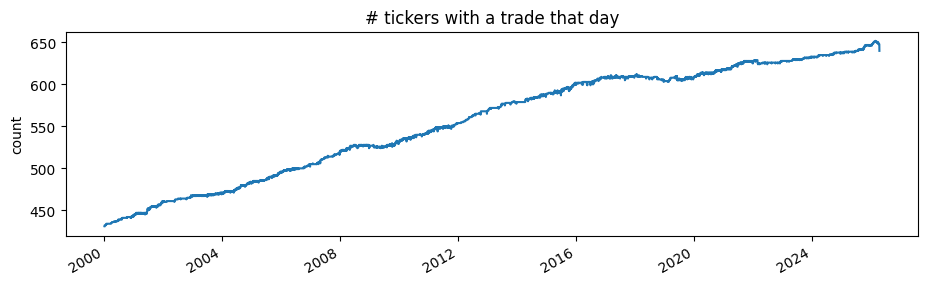

In [3]:
# Number of listed names per day — should grow over time and dip around the GFC / COVID
daily_count = df.groupby('date')['ticker'].nunique()
ax = daily_count.plot(figsize=(11, 3), title='# tickers with a trade that day')
ax.set_xlabel('')
ax.set_ylabel('count');

per-name ann. vol (median): 0.3624543414669675


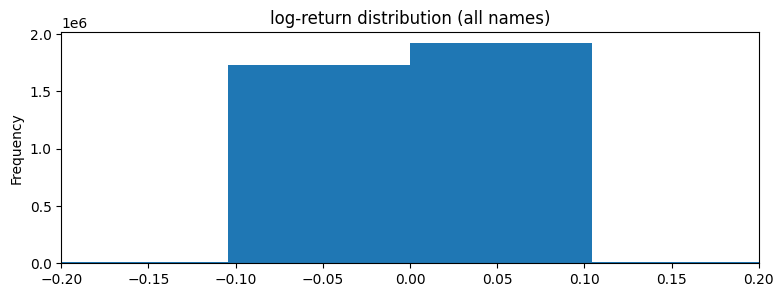

In [4]:
# Return distribution — quick sniff test for bad adjustments / stale prints
px = df.pivot(index='date', columns='ticker', values='adj_close').sort_index()
rets = np.log(px).diff()

print('per-name ann. vol (median):', rets.std().median() * np.sqrt(252))
rets.stack().plot.hist(bins=200, figsize=(9, 3), title='log-return distribution (all names)');
plt.xlim(-0.2, 0.2);

## Bias-free backtest primitives

Use `adj_close` for **return computation only**. For dollar-volume filters, size-based ranks, or any dollar-notional logic, use the raw `close` × `volume`.